In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv('global_ads_performance_dataset_100k.csv')

## Data Modeling

In [5]:
df.head()

,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
0,2022-01-01,TikTok Ads,Search,Fintech,UAE,68399,2296,0.0336,0.88,2016.14,124,16.26,4997.00,2.48
1,2022-01-01,TikTok Ads,Video,E-commerce,Australia,173943,3864,0.0222,0.70,2703.82,88,30.73,26842.25,9.93
2,2022-01-01,TikTok Ads,Display,E-commerce,Canada,63059,4037,0.0640,0.74,2997.18,74,40.50,4543.31,1.52
3,2022-01-01,TikTok Ads,Search,E-commerce,Canada,116182,4886,0.0421,0.94,4598.77,440,10.45,207157.49,45.05
4,2022-01-01,TikTok Ads,Display,SaaS,UK,94991,3940,0.0415,1.12,4397.21,260,16.91,24251.64,5.52


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   date           100000 non-null  object 
 1   platform       100000 non-null  object 
 2   campaign_type  100000 non-null  object 
 3   industry       100000 non-null  object 
 4   country        100000 non-null  object 
 5   impressions    100000 non-null  int64  
 6   clicks         100000 non-null  int64  
 7   CTR            100000 non-null  float64
 8   CPC            100000 non-null  float64
 9   ad_spend       100000 non-null  float64
 10  conversions    100000 non-null  int64  
 11  CPA            100000 non-null  float64
 12  revenue        100000 non-null  float64
 13  ROAS           100000 non-null  float64
dtypes: float64(6), int64(3), object(5)
memory usage: 10.7+ MB


In [7]:
## coverting the col names to lower caps
df.columns = df.columns.str.lower()
df.head()

,date,platform,campaign_type,industry,country,impressions,clicks,ctr,cpc,ad_spend,conversions,cpa,revenue,roas
0,2022-01-01,TikTok Ads,Search,Fintech,UAE,68399,2296,0.0336,0.88,2016.14,124,16.26,4997.00,2.48
1,2022-01-01,TikTok Ads,Video,E-commerce,Australia,173943,3864,0.0222,0.70,2703.82,88,30.73,26842.25,9.93
2,2022-01-01,TikTok Ads,Display,E-commerce,Canada,63059,4037,0.0640,0.74,2997.18,74,40.50,4543.31,1.52
3,2022-01-01,TikTok Ads,Search,E-commerce,Canada,116182,4886,0.0421,0.94,4598.77,440,10.45,207157.49,45.05
4,2022-01-01,TikTok Ads,Display,SaaS,UK,94991,3940,0.0415,1.12,4397.21,260,16.91,24251.64,5.52


In [8]:
df['country'].unique()

array(['UAE', 'Australia', 'Canada', 'UK', 'Germany', 'USA', 'India'],
      dtype=object)

In [9]:
df['campaign_type'].unique()

array(['Search', 'Video', 'Display', 'Shopping'], dtype=object)

In [10]:
df['platform'].unique()

array(['TikTok Ads', 'Google Ads', 'Meta Ads'], dtype=object)

In [11]:
df['industry'].unique()

array(['Fintech', 'E-commerce', 'SaaS', 'Healthcare', 'EdTech'],
      dtype=object)

In [12]:
## looking for nulls, duplicate values
df.isna().sum()



,0
date,0
platform,0
campaign_type,0
industry,0
country,0
impressions,0
clicks,0
ctr,0
cpc,0
ad_spend,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
## converting date col from object to date/time col
df['date'] = df['date'].astype('datetime64[ns]')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date           100000 non-null  datetime64[ns]
 1   platform       100000 non-null  object        
 2   campaign_type  100000 non-null  object        
 3   industry       100000 non-null  object        
 4   country        100000 non-null  object        
 5   impressions    100000 non-null  int64         
 6   clicks         100000 non-null  int64         
 7   ctr            100000 non-null  float64       
 8   cpc            100000 non-null  float64       
 9   ad_spend       100000 non-null  float64       
 10  conversions    100000 non-null  int64         
 11  cpa            100000 non-null  float64       
 12  revenue        100000 non-null  float64       
 13  roas           100000 non-null  float64       
dtypes: datetime64[ns](1), float64(6), int64(3), object(4)

In [16]:
df.head(1)

,date,platform,campaign_type,industry,country,impressions,clicks,ctr,cpc,ad_spend,conversions,cpa,revenue,roas
0,2022-01-01,TikTok Ads,Search,Fintech,UAE,68399,2296,0.0336,0.88,2016.14,124,16.26,4997.0,2.48


In [17]:
## looking for outliers
df.describe()

,date,impressions,clicks,ctr,cpc,ad_spend,conversions,cpa,revenue,roas
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000
mean,2023-07-01 20:16:26.399999744,102275.463280,3918.104600,0.038377,1.101433,4317.501855,175.863840,35.191913,2.864303e+04,6.644842
min,2022-01-01 00:00:00,5002.000000,25.000000,0.004900,0.200000,5.800000,1.000000,2.220000,2.700000e+00,0.100000
25%,2022-10-01 00:00:00,53880.000000,1199.000000,0.021900,0.810000,1139.335000,44.000000,16.410000,4.218850e+03,2.450000
50%,2023-07-03 00:00:00,102168.500000,3079.000000,0.037800,1.100000,2996.195000,119.000000,24.490000,1.233678e+04,4.490000
75%,2024-03-31 00:00:00,150759.250000,5790.000000,0.053400,1.390000,6169.757500,251.000000,37.390000,3.199644e+04,8.200000
max,2024-12-30 00:00:00,199997.000000,24109.000000,0.138500,2.920000,42073.260000,1807.000000,567.950000,1.489830e+06,50.000000
std,NaN,56090.206615,3293.175025,0.021416,0.425292,4232.140811,177.561523,41.199176,4.994391e+04,6.889232


In [18]:
df.skew(numeric_only=True)

,0
impressions,0.003712
clicks,1.117357
ctr,0.276323
cpc,0.094331
ad_spend,1.719189
conversions,1.778017
cpa,4.497755
revenue,5.614931
roas,2.859505


In [19]:
# Select the column you want to check
col = 'revenue'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# View outlier rows
outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
print(f"Found {len(outliers)} outliers in '{col}'")

Found 9370 outliers in 'revenue'


In [20]:
col = 'cpa'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# View outlier rows
outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
print(f"Found {len(outliers)} outliers in '{col}'")

Found 8170 outliers in 'cpa'


In [21]:
col = 'roas'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# View outlier rows
outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
print(f"Found {len(outliers)} outliers in '{col}'")

Found 7039 outliers in 'roas'


In [22]:
col = 'conversions'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# View outlier rows
outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
print(f"Found {len(outliers)} outliers in '{col}'")

Found 4274 outliers in 'conversions'


In [23]:
col = 'ad_spend'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# View outlier rows
outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
print(f"Found {len(outliers)} outliers in '{col}'")

Found 4043 outliers in 'ad_spend'


In [24]:
col = 'clicks'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# View outlier rows
outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
print(f"Found {len(outliers)} outliers in '{col}'")

Found 1802 outliers in 'clicks'


In [25]:
# List of columns where you found outliers
numeric_cols = ['revenue', 'cpa', 'roas', 'conversions', 'ad_spend', 'clicks']

# Cap values outside lower and upper IQR boundaries
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Clip values to bounds
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers capped successfully!")

Outliers capped successfully!


In [26]:
df.skew(numeric_only=True)

,0
impressions,0.003712
clicks,0.937356
ctr,0.276323
cpc,0.094331
ad_spend,1.072696
conversions,1.088004
cpa,0.952280
revenue,1.175909
roas,1.077298


## EDA

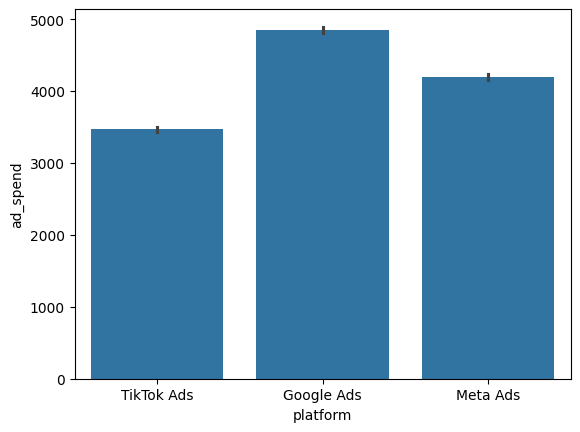

In [27]:
##Ad Budget Distribution Analysis
sns.barplot(x=df['platform'], y=df['ad_spend'])
plt.show()

Most ad budget is spent on **Google Ads** followed by Meta Ads and TikTok Ads

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date           100000 non-null  datetime64[ns]
 1   platform       100000 non-null  object        
 2   campaign_type  100000 non-null  object        
 3   industry       100000 non-null  object        
 4   country        100000 non-null  object        
 5   impressions    100000 non-null  int64         
 6   clicks         100000 non-null  float64       
 7   ctr            100000 non-null  float64       
 8   cpc            100000 non-null  float64       
 9   ad_spend       100000 non-null  float64       
 10  conversions    100000 non-null  float64       
 11  cpa            100000 non-null  float64       
 12  revenue        100000 non-null  float64       
 13  roas           100000 non-null  float64       
dtypes: datetime64[ns](1), float64(8), int64(1), object(4)

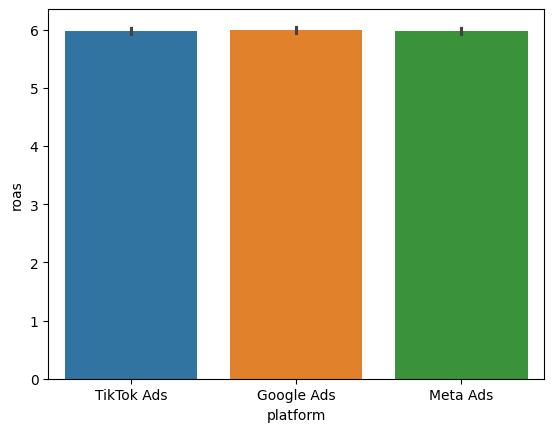

In [29]:
##Which platform delivers the best ROAS overall?
sns.barplot(x=df['platform'], y=df['roas'], hue = 'platform', data = df)
plt.show()

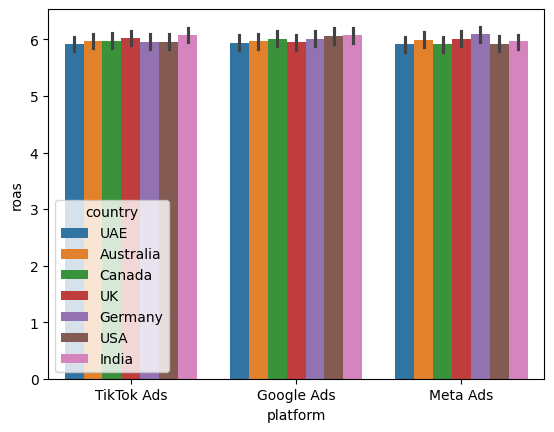

In [30]:
#Is that consistent across all countries, or does it flip depending on market?
sns.barplot(x=df['platform'], y=df['roas'], hue = 'country', data = df)
plt.show()

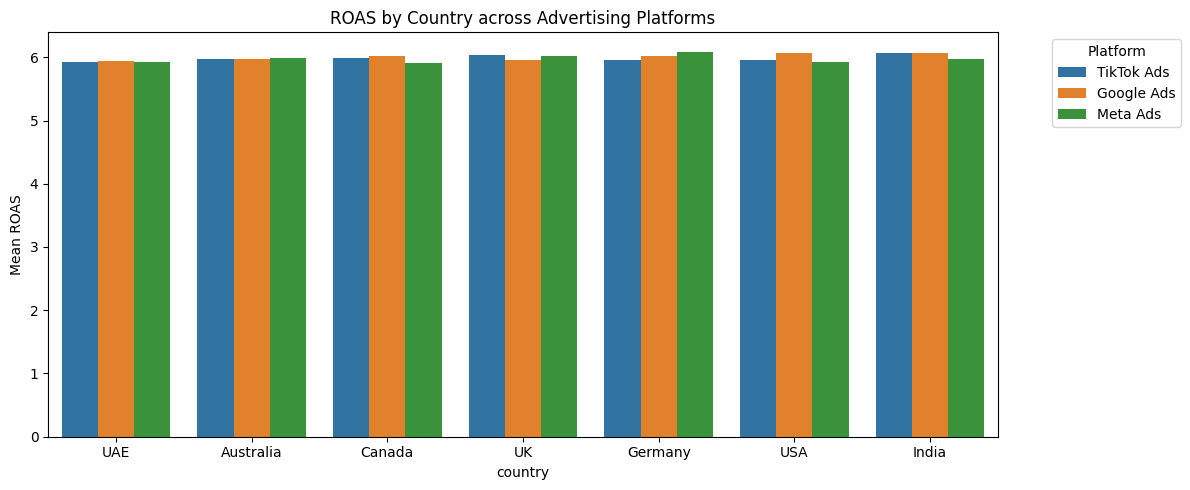

In [31]:
plt.figure(figsize=(12, 5))
sns.barplot(data=df, x='country', y='roas', hue='platform', errorbar=None)
plt.title('ROAS by Country across Advertising Platforms')
plt.ylabel('Mean ROAS')
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##it stays consistents across all platform but india and germany slightly leads on tiktok

/tmp/ipykernel_8471/3947425287.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=df['campaign_type'], y=df['cpa'], hue = 'campaign_type', data = df, ci = None)


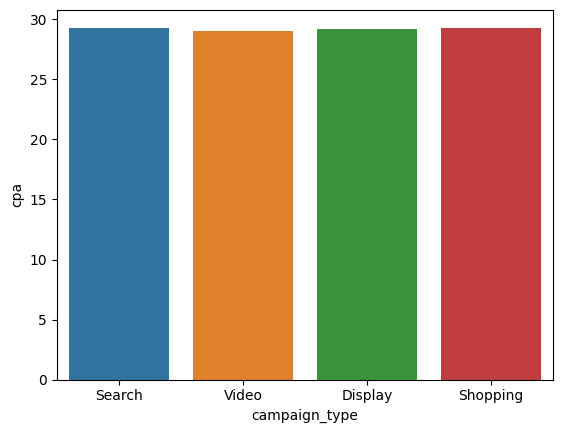

In [32]:
##Which campaign type (Search, Video, Shopping, Display) is most cost-efficient on a CPA basis?
sns.barplot(x=df['campaign_type'], y=df['cpa'], hue = 'campaign_type', data = df, ci = None)
plt.show()

## Video is slightly cos-efficient based on cpa

/tmp/ipykernel_8471/1026797608.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='campaign_type', y='ad_spend', ax=axes[0], errorbar=None, palette='Reds_d')
/tmp/ipykernel_8471/1026797608.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='campaign_type', y='revenue', ax=axes[1], errorbar=None, palette='Greens_d')


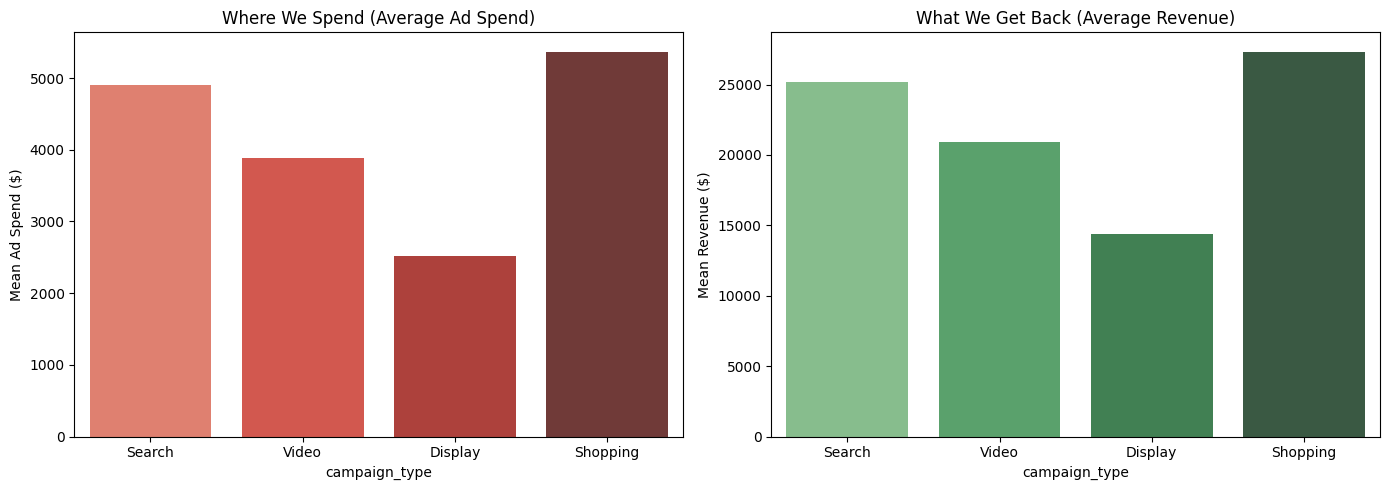

In [33]:
##Are we spending the most money on the platforms that actually perform best, or is budget misallocated?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Where the money is spent
sns.barplot(data=df, x='campaign_type', y='ad_spend', ax=axes[0], errorbar=None, palette='Reds_d')
axes[0].set_title('Where We Spend (Average Ad Spend)')
axes[0].set_ylabel('Mean Ad Spend ($)')

# Plot 2: Where the return is highest
sns.barplot(data=df, x='campaign_type', y='revenue', ax=axes[1], errorbar=None, palette='Greens_d')
axes[1].set_title('What We Get Back (Average Revenue)')
axes[1].set_ylabel('Mean Revenue ($)')

plt.tight_layout()
plt.show()

##Shift budget away from standard Shopping/Search and double down on Video campaigns

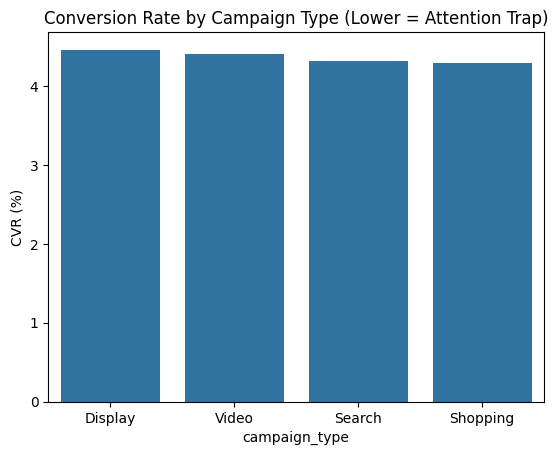

In [34]:
##Which combinations have high impressions/clicks but poor conversion — where are we "buying attention" without buying results?
# 1. Calculate Conversion Rate (CVR) by Campaign Type
trap_data = df.groupby('campaign_type')[['clicks', 'conversions']].sum().reset_index()
trap_data['cvr_percent'] = (trap_data['conversions'] / trap_data['clicks']) * 100

# Sort from highest to lowest CVR
trap_data = trap_data.sort_values(by='cvr_percent', ascending=False)

# 2. Plot the basic graph
sns.barplot(data=trap_data, x='campaign_type', y='cvr_percent')
plt.title('Conversion Rate by Campaign Type (Lower = Attention Trap)')
plt.ylabel('CVR (%)')
plt.show()

In [35]:
##Which countries are our top 3 and bottom 3 markets by ROAS? By CPA?

# Calculate mean ROAS and CPA by country
country_perf = df.groupby('country')[['roas', 'cpa']].mean().reset_index()

# 1. Answer the ROAS question
print("🏆 TOP 3 Markets by ROAS:")
print(country_perf.sort_values(by='roas', ascending=False).head(3))

print("\n📉 BOTTOM 3 Markets by ROAS:")
print(country_perf.sort_values(by='roas', ascending=True).head(3))

# 2. Answer the CPA question (Remember: Lower CPA is better!)
print("\n🏆 TOP 3 Markets by CPA (Lowest Cost):")
print(country_perf.sort_values(by='cpa', ascending=True).head(3))

print("\n📉 BOTTOM 3 Markets by CPA (Highest Cost):")
print(country_perf.sort_values(by='cpa', ascending=False).head(3))

🏆 TOP 3 Markets by ROAS:
   country      roas        cpa
3    India  6.037969  29.358873
2  Germany  6.020559  29.076411
5       UK  6.000793  29.142550

📉 BOTTOM 3 Markets by ROAS:
     country      roas        cpa
4        UAE  5.925777  29.167975
1     Canada  5.969072  29.397768
0  Australia  5.974716  29.059967

🏆 TOP 3 Markets by CPA (Lowest Cost):
     country      roas        cpa
0  Australia  5.974716  29.059967
2    Germany  6.020559  29.076411
6        USA  5.979727  29.113092

📉 BOTTOM 3 Markets by CPA (Highest Cost):
  country      roas        cpa
1  Canada  5.969072  29.397768
3   India  6.037969  29.358873
4     UAE  5.925777  29.167975


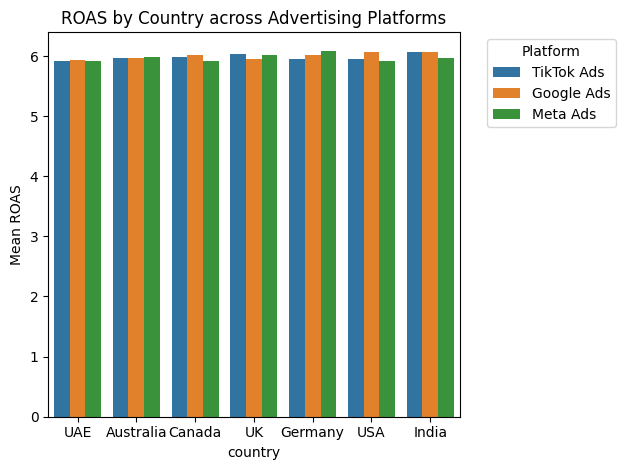

In [36]:
##Is there a country where one platform dramatically outperforms the others — something we could exploit?
sns.barplot(data=df, x='country', y='roas', hue='platform', errorbar=None)
plt.title('ROAS by Country across Advertising Platforms')
plt.ylabel('Mean ROAS')
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


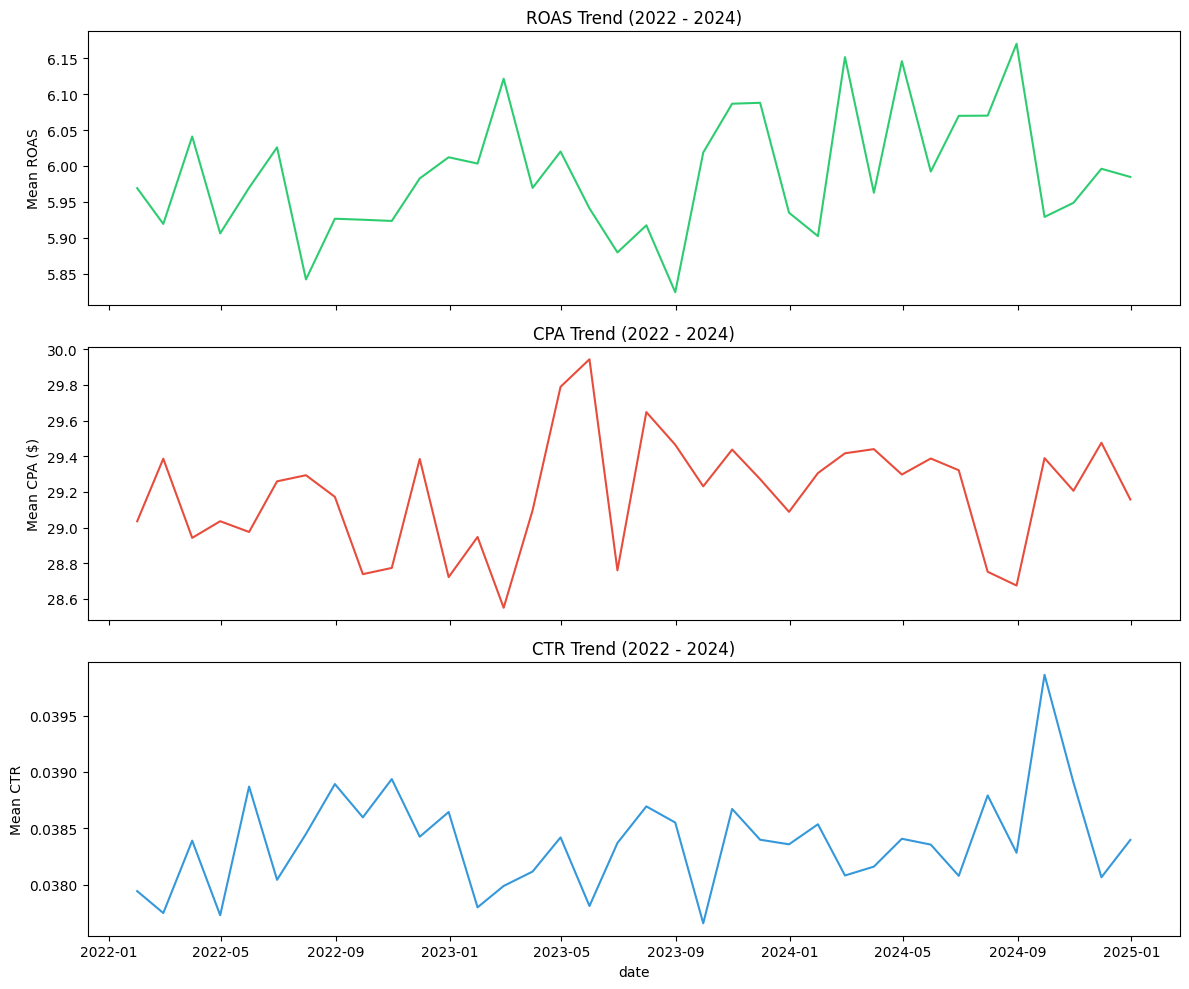

In [39]:
##Has performance (ROAS, CPA, CTR) improved, declined, or stayed flat from 2022 to 2024? Any seasonality — do certain months/quarters consistently perform better?

# Set date as index to allow time-based resampling
df_time = df.set_index('date')

# Aggregate by Month ('ME' = Month End) and calculate the mean
monthly_trend = df_time[['roas', 'cpa', 'ctr']].resample('ME').mean()

# Plot the trends in a stacked 3-part chart
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

sns.lineplot(data=monthly_trend, x=monthly_trend.index, y='roas', ax=axes[0], color='#2ecc71')
axes[0].set_title('ROAS Trend (2022 - 2024)')
axes[0].set_ylabel('Mean ROAS')

sns.lineplot(data=monthly_trend, x=monthly_trend.index, y='cpa', ax=axes[1], color='#e74c3c')
axes[1].set_title('CPA Trend (2022 - 2024)')
axes[1].set_ylabel('Mean CPA ($)')

sns.lineplot(data=monthly_trend, x=monthly_trend.index, y='ctr', ax=axes[2], color='#3498db')
axes[2].set_title('CTR Trend (2022 - 2024)')
axes[2].set_ylabel('Mean CTR')

plt.tight_layout()
plt.show()

/tmp/ipykernel_8471/3630199598.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='quarter', y='roas', errorbar=None, palette='viridis')


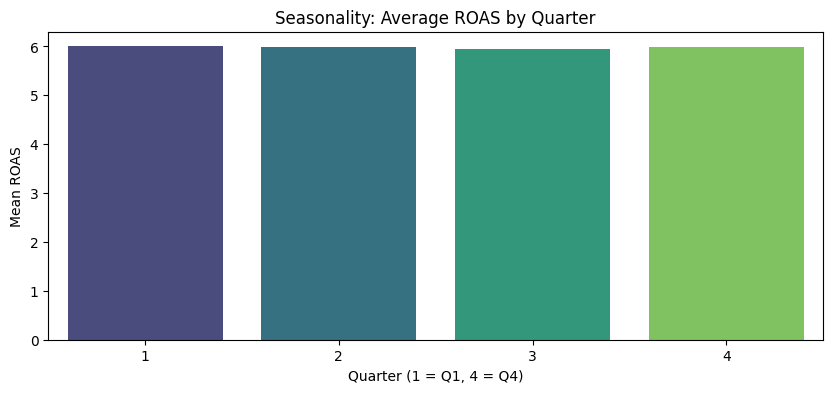

📊 Seasonality Breakdown (By Quarter):
          roas     cpa    ctr
quarter                      
1        6.002  29.130  0.038
2        5.994  29.309  0.038
3        5.958  29.152  0.039
4        5.995  29.165  0.039


In [40]:
# Create new columns for Month and Quarter
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter

# Check Quarter Seasonality for ROAS and CPA
plt.figure(figsize=(10, 4))
sns.barplot(data=df, x='quarter', y='roas', errorbar=None, palette='viridis')

plt.title('Seasonality: Average ROAS by Quarter')
plt.xlabel('Quarter (1 = Q1, 4 = Q4)')
plt.ylabel('Mean ROAS')

plt.show()

# Print the exact numbers to see if differences are significant
print("📊 Seasonality Breakdown (By Quarter):")
print(df.groupby('quarter')[['roas', 'cpa', 'ctr']].mean().round(3))

##Conclusion
**1. Shift Budget Away from Search/Shopping & Double Down on Video**

The Data: Currently, the lion's share of the ad budget is heavily concentrated in Search and Shopping campaigns. However, our analysis reveals that Video campaigns are the most cost-efficient channel based on Cost Per Acquisition (CPA).

Action: Reallocate 15-20% of the budget from Search/Shopping into Video to capitalize on its high efficiency and drive down the overall blended CPA.

**2. Cut Spend on Display Campaigns (The "Attention Trap")**

The Data: Display campaigns are generating high click volume but suffer from the lowest Conversion Rate (CVR) across all campaign types.

Action: Reduce investment in Display. We are currently "buying attention" without driving meaningful revenue results. Redirect these funds to higher-converting campaign types.

**3. Diversify Platform Spend & Exploit TikTok in Key Geo-Markets**

The Data: The vast majority of the budget is currently defaulting to Google Ads. Yet, Return on Ad Spend (ROAS) is remarkably consistent (hovering around 6.0) across Meta, Google, and TikTok.

Action: Stop treating Google as the default. Since performance is flat across platforms, we have the flexibility to diversify. Specifically, we should aggressively test increasing TikTok Ads spend in India and Germany, where it shows a slight performance edge over the other platforms.

**4. Prioritize "Sweet Spot" Geographies (Like Germany)**

The Data: Germany is a massive outlier for efficiency, ranking in the Top 3 for both highest ROAS (6.02) and lowest CPA ($29.07). India also drives the highest overall ROAS (6.03). Conversely, the UAE and Canada sit at the bottom for ROAS.

Action: Shift geo-targeted budgets to prioritize Germany and India. Scale back slightly in the UAE and Canada until we can optimize their specific campaign creatives.

**5. Adopt an "Always-On" Pacing Strategy (Ignore Seasonality)**

The Data: The quarterly breakdown shows almost zero seasonal variance, with ROAS remaining completely flat between 5.95 and 6.00 across all four quarters.

Action: Do not hoard the marketing budget for Q4 or holiday spikes. The business is highly "evergreen," meaning steady, consistent ad pacing throughout the year will yield the most reliable revenue.

## Applying ML model

In [85]:
df.dropna(subset=['revenue'], inplace=True)

In [98]:
df['cvr'] = df['conversions'] / df['clicks']

In [99]:
features = ['platform', 'campaign_type', 'industry', 'country',
            'impressions', 'clicks', 'ctr', 'cpc', 'ad_spend', 'cpa',
            'conversions', 'month', 'quarter', 'cvr']

In [100]:
X = pd.get_dummies(df[features], drop_first=True)
y = df['revenue']

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [102]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [108]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(x_train, y_train)

RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

In [109]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
y_pred = rf_model.predict(x_test)

In [110]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
accuracy_percent = r2 * 100

In [111]:
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Model Accuracy (R-squared): {accuracy_percent:.2f}%")

MAE:  11797.1912
MSE:  275673182.3292
RMSE: 16603.4088
Model Accuracy (R-squared): 48.94%


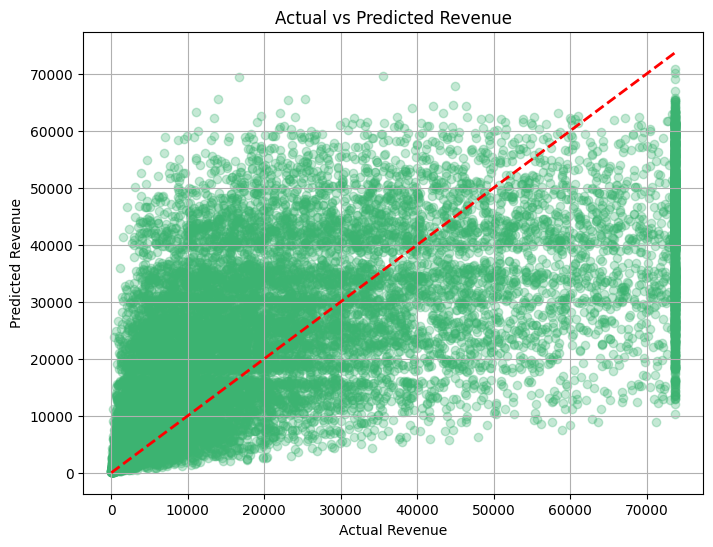

In [112]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='mediumseagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title("Actual vs Predicted Revenue")
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.grid(True)
plt.show()